# Predictive Modeling for Silica Concentration in Mining Flotation Process
##### DataSource: <https://www.kaggle.com/datasets/edumagalhaes/quality-prediction-in-a-mining-process>
## Project Overview:
This study aims to develop a machine learning model to predict the percentage of silica in the final product of a mining flotation process. The project utilizes data from Kaggle's "Quality Prediction in a Mining Process" dataset.

## Key Objectives:
- Enhance process reliability
- Minimize environmental impact by reducing wastewater
- Optimize operational costs by decreasing reliance on laboratory testing

## Primary Findings:
- **Model Selection:** Random Forest algorithm chosen for deployment
- **Model Performance:**
  - Root Mean Square Error (RMSE): 0.185
  - Coefficient of Determination (R²): 0.853R²): 0.853 - R2: 0.853

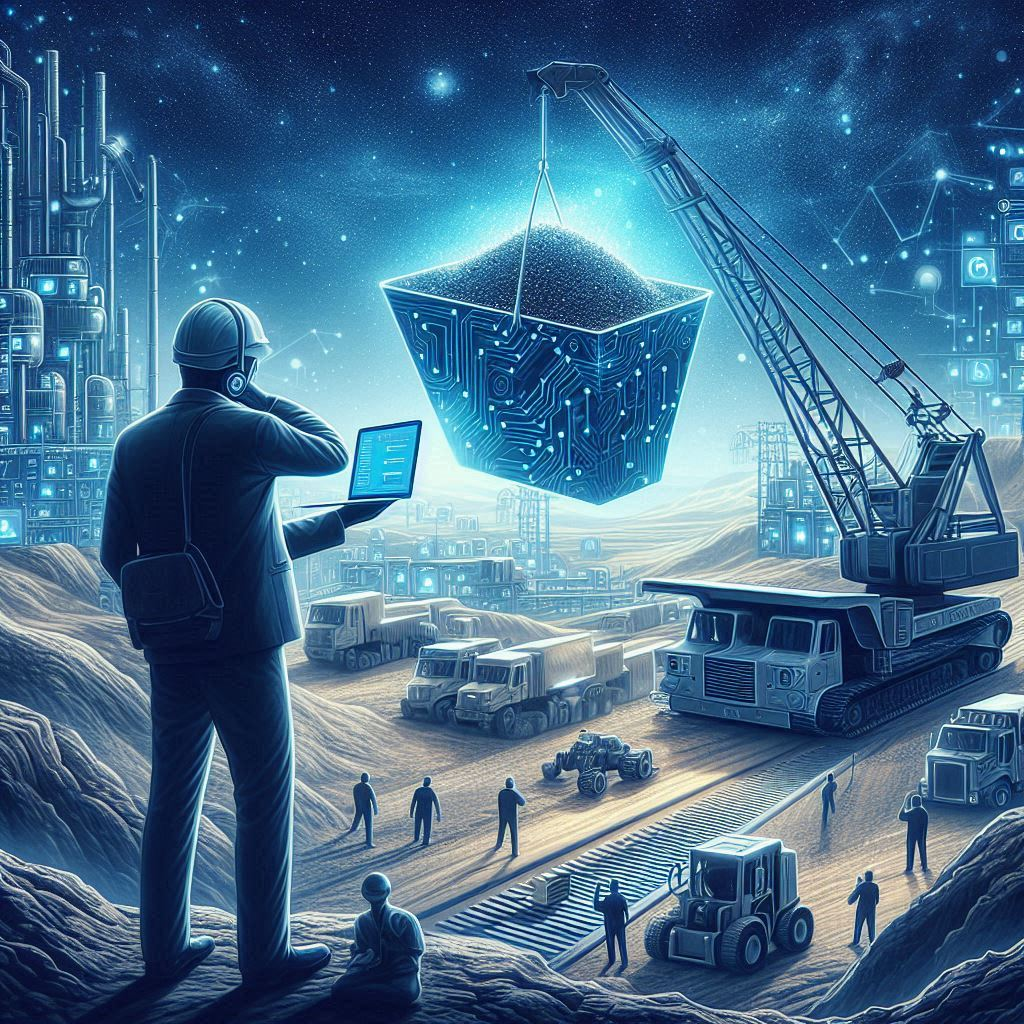

### Import  library 


In [31]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor

from sklearn.metrics import mean_squared_error, r2_score


### Load Data

In [32]:
data = pd.read_csv('../Datasets/MiningProcess_Flotation_Plant_Database.csv')


In [33]:
data.head()

,date,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
0,2017-03-10 01:00:00,"55,2","16,98","3019,53","557,434","395,713","10,0664","1,74","249,214","253,235",...,"250,884","457,396","432,962","424,954","443,558","502,255","446,37","523,344","66,91","1,31"
1,2017-03-10 01:00:00,"55,2","16,98","3024,41","563,965","397,383","10,0672","1,74","249,719","250,532",...,"248,994","451,891","429,56","432,939","448,086","496,363","445,922","498,075","66,91","1,31"
2,2017-03-10 01:00:00,"55,2","16,98","3043,46","568,054","399,668","10,068","1,74","249,741","247,874",...,"248,071","451,24","468,927","434,61","449,688","484,411","447,826","458,567","66,91","1,31"
3,2017-03-10 01:00:00,"55,2","16,98","3047,36","568,665","397,939","10,0689","1,74","249,917","254,487",...,"251,147","452,441","458,165","442,865","446,21","471,411","437,69","427,669","66,91","1,31"
4,2017-03-10 01:00:00,"55,2","16,98","3033,69","558,167","400,254","10,0697","1,74","250,203","252,136",...,"248,928","452,441","452,9","450,523","453,67","462,598","443,682","425,679","66,91","1,31"


In [34]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 737453 entries, 0 to 737452
Data columns (total 24 columns):
 #   Column                        Non-Null Count   Dtype 
---  ------                        --------------   ----- 
 0   date                          737453 non-null  object
 1   % Iron Feed                   737453 non-null  object
 2   % Silica Feed                 737453 non-null  object
 3   Starch Flow                   737453 non-null  object
 4   Amina Flow                    737453 non-null  object
 5   Ore Pulp Flow                 737453 non-null  object
 6   Ore Pulp pH                   737453 non-null  object
 7   Ore Pulp Density              737453 non-null  object
 8   Flotation Column 01 Air Flow  737453 non-null  object
 9   Flotation Column 02 Air Flow  737453 non-null  object
 10  Flotation Column 03 Air Flow  737453 non-null  object
 11  Flotation Column 04 Air Flow  737453 non-null  object
 12  Flotation Column 05 Air Flow  737453 non-null  object
 13 

In [35]:
TIMESTAMP_COL = 'date'
data[TIMESTAMP_COL] = pd.to_datetime(data[TIMESTAMP_COL])

columnas_objeto = data.select_dtypes(include=['object']).columns

print("Limpiando datos: Reemplazando comas por puntos y convirtiendo a números...")
for col in columnas_objeto:
    # errors='coerce' transforma cualquier texto extraño que no sea un
    # número en NaN — así cualquier fila corrupta se hace visible en el
    # chequeo de missingness del Paso E, en vez de fallar en silencio.
    data[col] = pd.to_numeric(data[col].astype(str).str.replace(',', '.'), errors='coerce')

print("Limpieza completada.\n")
print("Tipos de datos tras limpieza:")
print(data.dtypes.value_counts())

data=data.drop('date',axis=1)

numeric_cols = data.select_dtypes(include=np.number).columns.tolist()

Limpiando datos: Reemplazando comas por puntos y convirtiendo a números...
Limpieza completada.

Tipos de datos tras limpieza:
float64           23
datetime64[ns]     1
Name: count, dtype: int64


### Clean Data

In [36]:
data.head()

,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,Flotation Column 03 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
0,55.2,16.98,3019.53,557.434,395.713,10.0664,1.74,249.214,253.235,250.576,...,250.884,457.396,432.962,424.954,443.558,502.255,446.370,523.344,66.91,1.31
1,55.2,16.98,3024.41,563.965,397.383,10.0672,1.74,249.719,250.532,250.862,...,248.994,451.891,429.560,432.939,448.086,496.363,445.922,498.075,66.91,1.31
2,55.2,16.98,3043.46,568.054,399.668,10.0680,1.74,249.741,247.874,250.313,...,248.071,451.240,468.927,434.610,449.688,484.411,447.826,458.567,66.91,1.31
3,55.2,16.98,3047.36,568.665,397.939,10.0689,1.74,249.917,254.487,250.049,...,251.147,452.441,458.165,442.865,446.210,471.411,437.690,427.669,66.91,1.31
4,55.2,16.98,3033.69,558.167,400.254,10.0697,1.74,250.203,252.136,249.895,...,248.928,452.441,452.900,450.523,453.670,462.598,443.682,425.679,66.91,1.31


### Data exploration

In [37]:
print(data.isnull().sum())


% Iron Feed                     0
% Silica Feed                   0
Starch Flow                     0
Amina Flow                      0
Ore Pulp Flow                   0
Ore Pulp pH                     0
Ore Pulp Density                0
Flotation Column 01 Air Flow    0
Flotation Column 02 Air Flow    0
Flotation Column 03 Air Flow    0
Flotation Column 04 Air Flow    0
Flotation Column 05 Air Flow    0
Flotation Column 06 Air Flow    0
Flotation Column 07 Air Flow    0
Flotation Column 01 Level       0
Flotation Column 02 Level       0
Flotation Column 03 Level       0
Flotation Column 04 Level       0
Flotation Column 05 Level       0
Flotation Column 06 Level       0
Flotation Column 07 Level       0
% Iron Concentrate              0
% Silica Concentrate            0
dtype: int64


In [38]:
data.describe()

,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,Flotation Column 03 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
count,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,...,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000
mean,56.294739,14.651716,2869.140569,488.144697,397.578372,9.767639,1.680380,280.151856,277.159965,281.082397,...,290.754856,520.244823,522.649555,531.352662,420.320973,425.251706,429.941018,421.021231,65.050068,2.326763
std,5.157744,6.807439,1215.203734,91.230534,9.699785,0.387007,0.069249,29.621288,30.149357,28.558268,...,28.670105,131.014924,128.165050,150.842164,91.794432,84.535822,89.862225,84.891491,1.118645,1.125554
min,42.740000,1.310000,0.002026,241.669000,376.249000,8.753340,1.519820,175.510000,175.156000,176.469000,...,185.962000,149.218000,210.752000,126.255000,162.201000,166.991000,155.841000,175.349000,62.050000,0.600000
25%,52.670000,8.940000,2076.320000,431.796000,394.264000,9.527360,1.647310,250.281000,250.457000,250.855000,...,256.302000,416.978000,441.883000,411.325000,356.679000,357.653000,358.497000,356.772000,64.370000,1.440000
50%,56.080000,13.850000,3018.430000,504.393000,399.249000,9.798100,1.697600,299.344000,296.223000,298.696000,...,299.011000,491.878000,495.956000,494.318000,411.974000,408.773000,424.664575,411.065000,65.210000,2.000000
75%,59.720000,19.600000,3727.730000,553.257000,402.968000,10.038000,1.728330,300.149000,300.690000,300.382000,...,301.904000,594.114000,595.464000,601.249000,485.549000,484.329000,492.684000,476.465000,65.860000,3.010000
max,65.780000,33.400000,6300.230000,739.538000,418.641000,10.808100,1.853250,373.871000,375.992000,364.346000,...,371.593000,862.274000,828.919000,886.822000,680.359000,675.644000,698.861000,659.902000,68.010000,5.530000


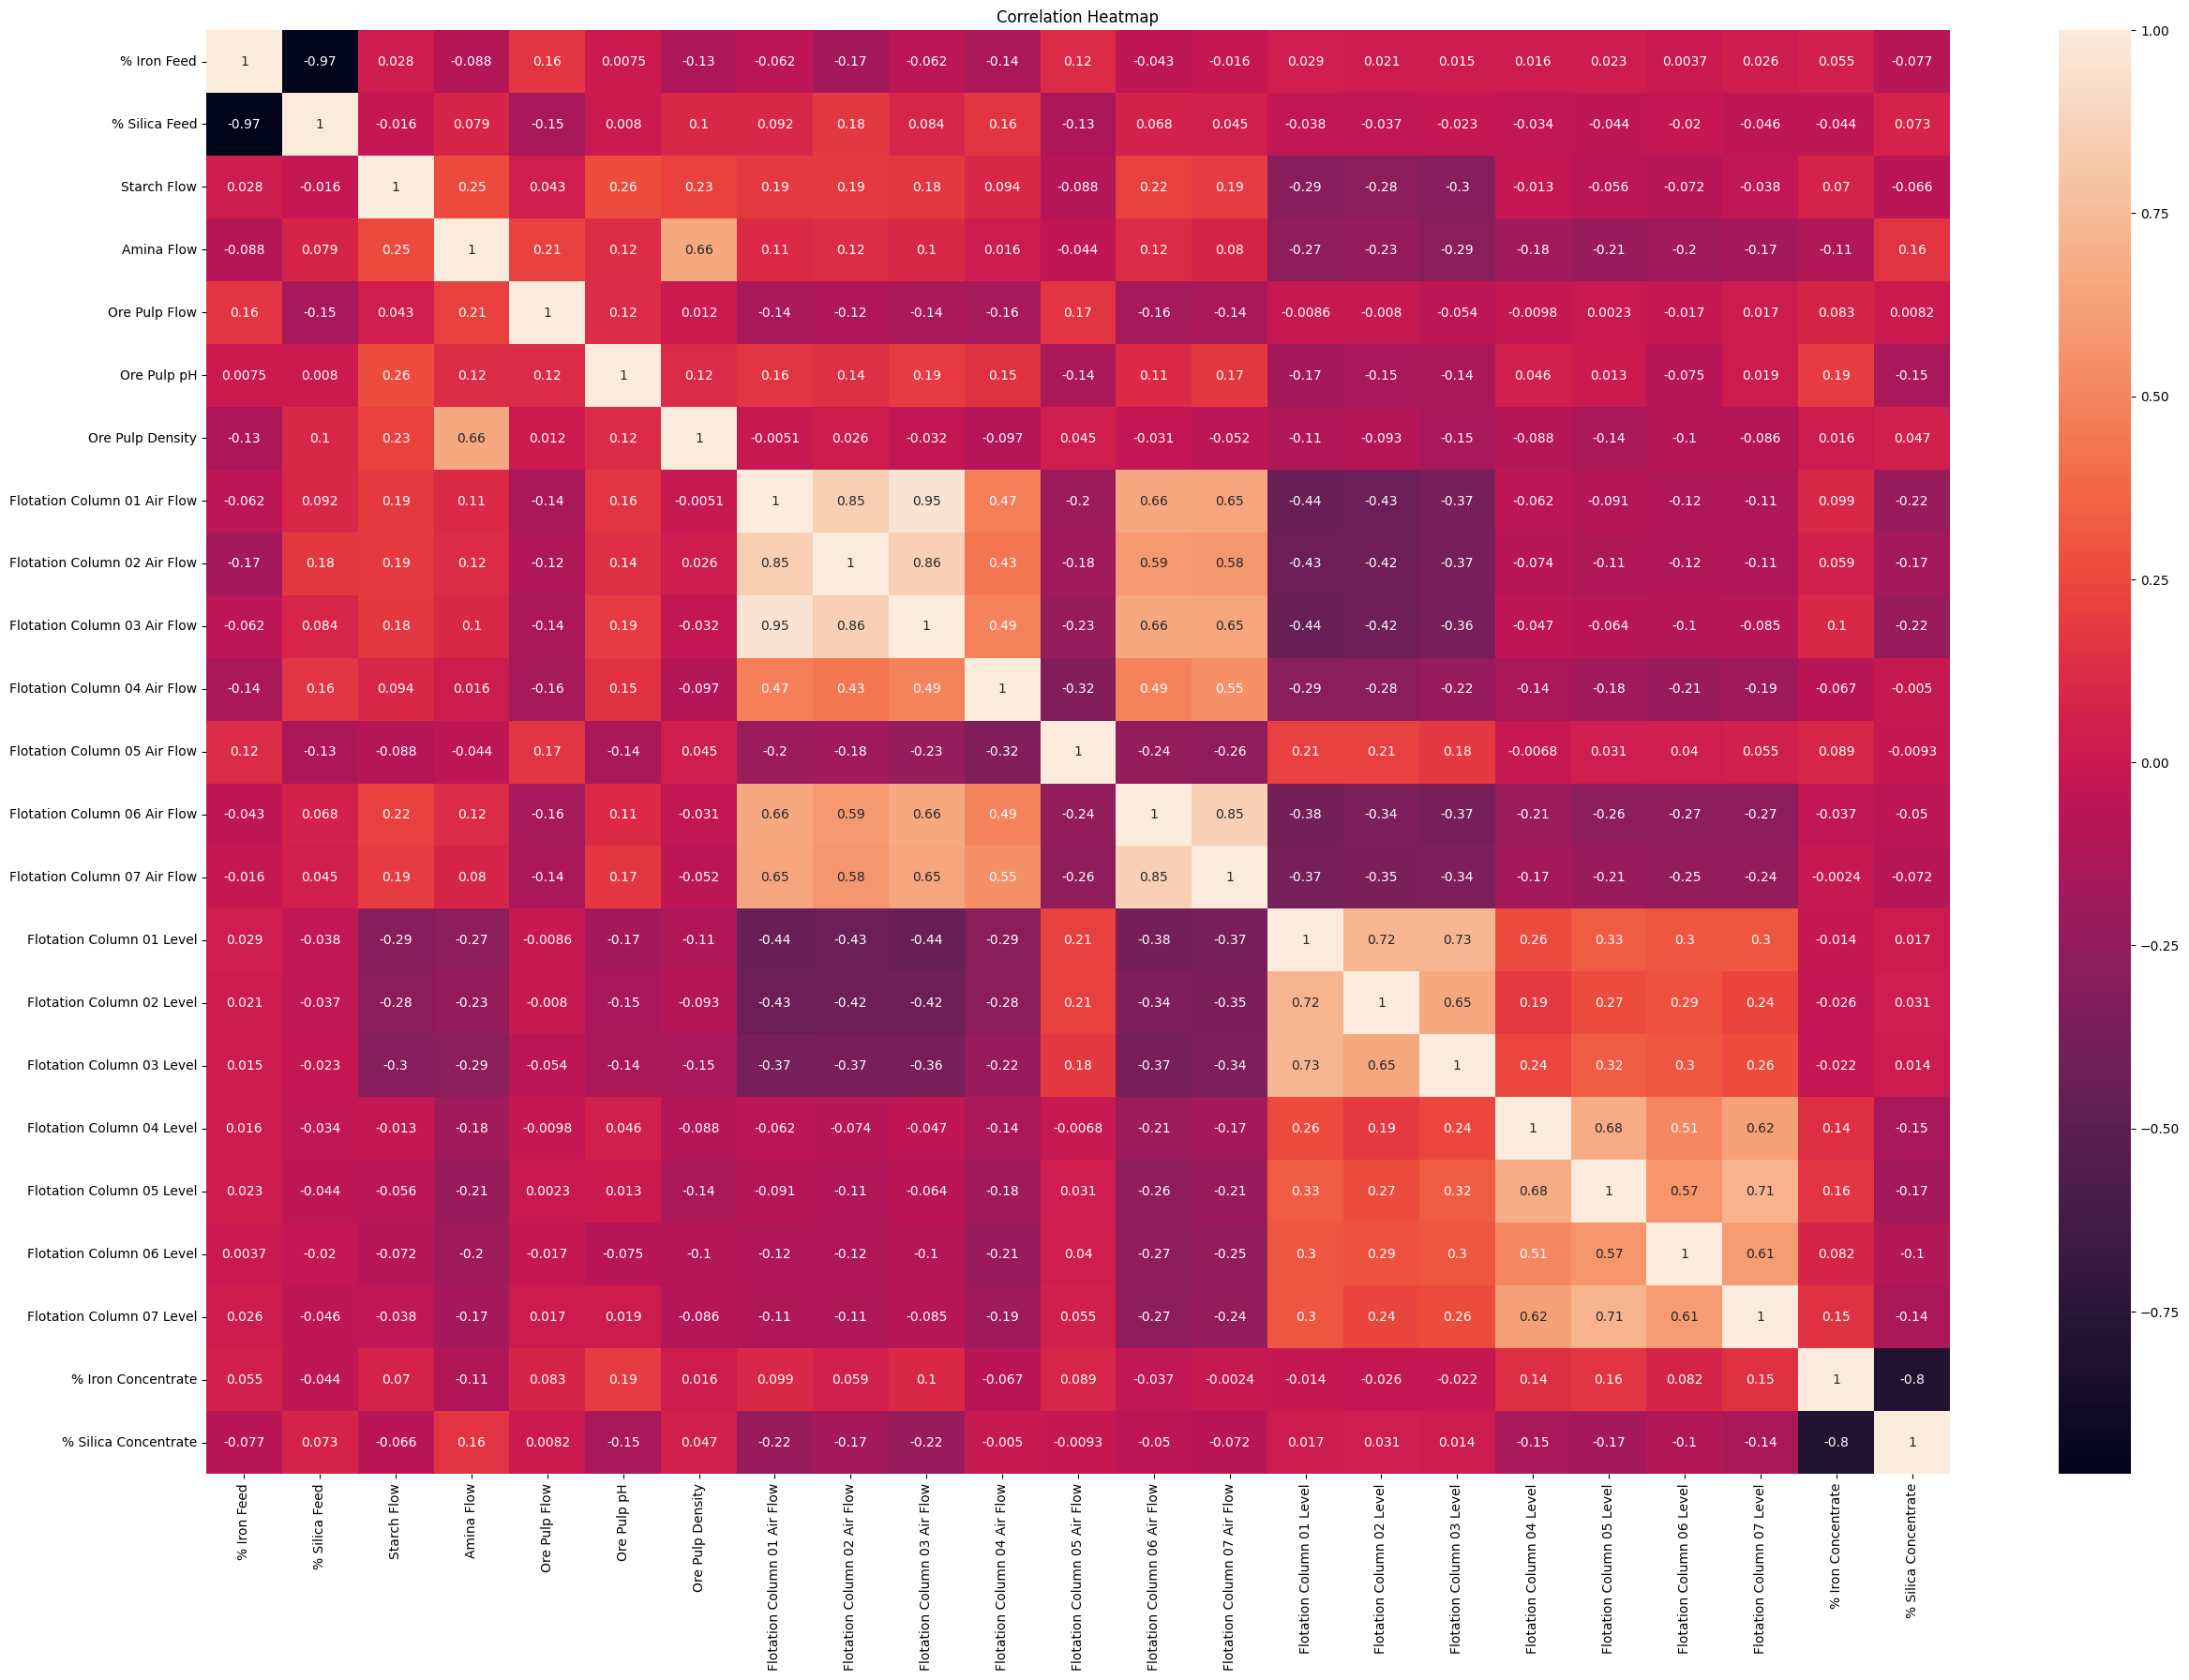

In [39]:
#data corrleation

plt.figure(figsize=(30,20))
sns.heatmap(data.corr(),annot=True)
plt.title('Correlation Heatmap')
plt.show()

##### From Correlation Matrix, possible features relating with label are as follows:
    
- iron concentrate
- amina flow
- ore pulp flow
- ore pulp density
- flotation air flow (01|02|03)
- flotation column level (04|05|06|07)
- % silica feed (**Added by sense of my mind)e of my mind)

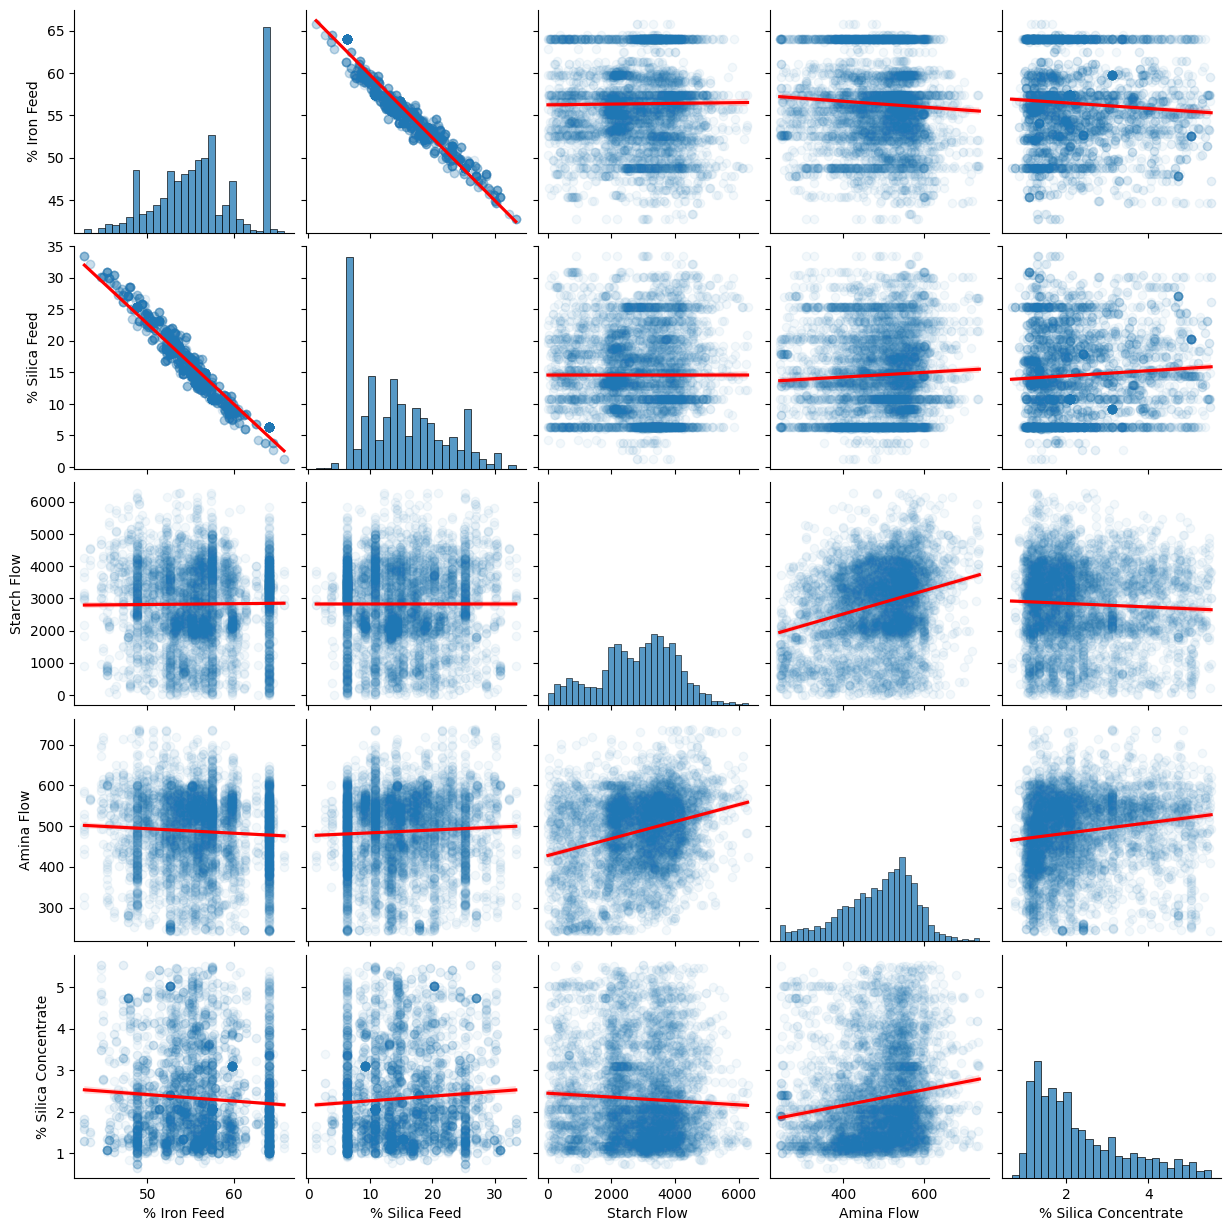

In [40]:
# Graficar solo 5000 filas aleatorias te dará la misma información visual en 2 segundos
sns.pairplot(
    data.sample(5000), # <--- El truco está aquí
    vars=['% Iron Feed', '% Silica Feed', 'Starch Flow', 'Amina Flow', '% Silica Concentrate'],
    kind='reg',
    plot_kws={'scatter_kws': {'alpha': 0.05}, 'line_kws': {'color': 'red'}}
)
plt.show()

There's a weak positive correlation between % Silica Feed and % Silica Concentrate, which is logical.
A weak negative correlation exists between % Iron Feed and % Silica Concentrate, also as expected.

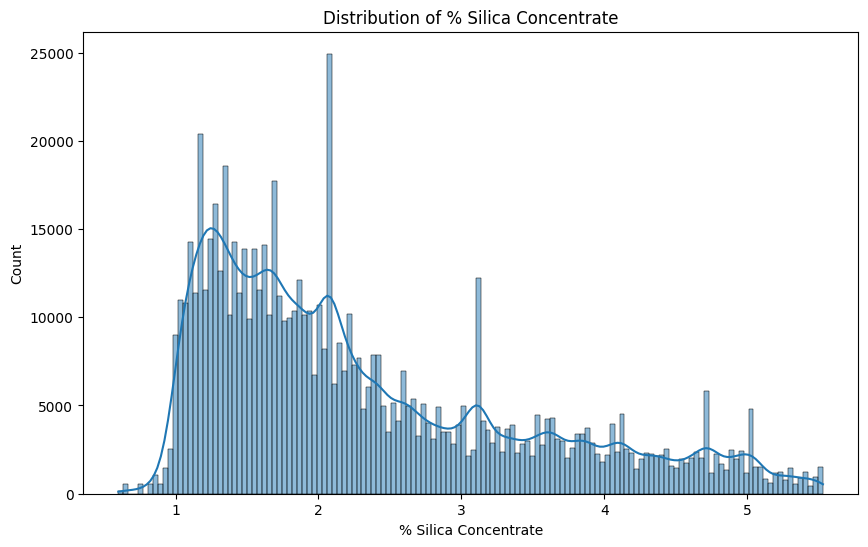

In [41]:
# Distribution of target variable
plt.figure(figsize=(10, 6))
sns.histplot(data['% Silica Concentrate'], kde=True)
plt.title('Distribution of % Silica Concentrate')
plt.show()

The distribution of % Silica Concentrate is right-skewed, with a peak around 1-2%. Values range from 0.5% to 5%, with most falling between 1-3%. Multiple smaller peaks suggest varied operating conditions. The process appears well-controlled, keeping silica levels low, but there's room for improvement in reducing higher concentrations.


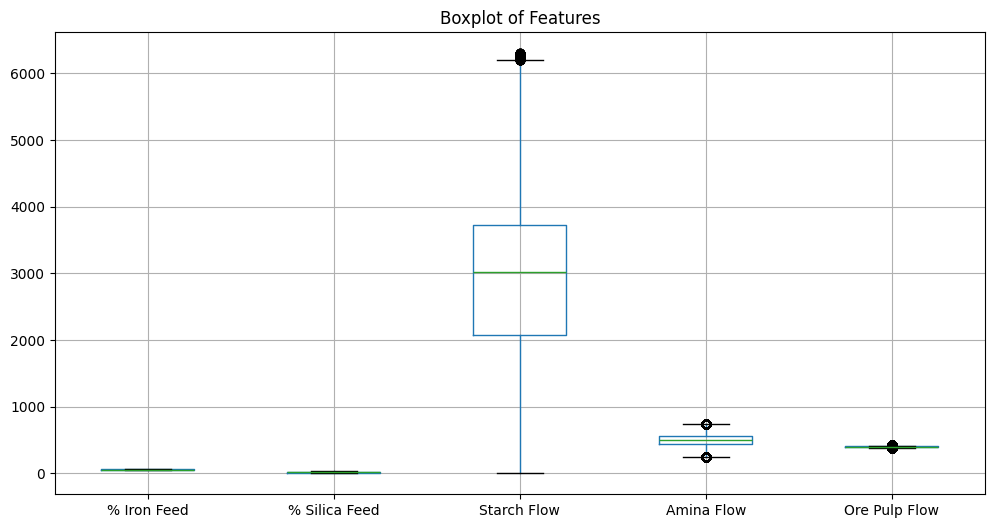

In [42]:
# Boxplot to check for outliers
plt.figure(figsize=(12, 6))
data.boxplot(column=['% Iron Feed', '% Silica Feed', 'Starch Flow', 'Amina Flow', 'Ore Pulp Flow'])
plt.title('Boxplot of Features')
plt.show()

Starch Flow and Amina Flow show the most prominent outliers, particularly on the upper end of their distributions.


###  Data Cleaning (again)

In [71]:
# Action1: Select only the possible features, drop other column

droplist=['% Iron Feed','Starch Flow',\
          'Ore Pulp pH','Flotation Column 02 Air Flow',\
          'Flotation Column 03 Air Flow', 'Flotation Column 04 Air Flow',\
          'Flotation Column 05 Air Flow', 'Flotation Column 06 Air Flow',\
          'Flotation Column 07 Air Flow/', 'Flotation Column 01 Level',
          'Flotation Column 02 Level', 'Flotation Column 03 Level', 'Flotation Column 05 Level',
          'Flotation Column 06 Level', 'Flotation Column 07 Level', '% Iron Concentrate']

# Create a set of columns to drop that are actually in the DataFrame
columns_to_drop = set(droplist) & set(data.columns)

# Drop the columns
data_2 = data.drop(columns=columns_to_drop)

# Check the new shape of the DataFrame
print(data_2.shape)

(737453, 8)


In [ ]:
def construir_features(df, variables_entrada, usar_lags=True, n_lags=3,
                        espaciado_lags='consecutivo', base_potencia=2,
                        usar_rolling_mean=False, ventana_mean=5,
                        usar_rolling_std=False, ventana_std=5,
                        usar_diff=False):
    df_out = df.copy()
    columnas_features = list(variables_entrada)

    lista_lags = list(range(1, n_lags + 1))

    # Acumulamos las columnas nuevas en un diccionario y las unimos con UN solo concat al
    # final, en vez de insertarlas una a una con df_out[col] = ... . Insertar columna a
    # columna fragmenta el DataFrame internamente (pandas avisa con PerformanceWarning) y
    # es notablemente más lento cuando esta función se llama muchas veces seguidas -- como
    # ocurre en construir_features_multi_sim, que la invoca una vez POR CADA simulación.
    nuevas_columnas = {}
    for var in variables_entrada:
        if usar_lags:
            for lag in lista_lags:
                col = f'{var}_lag_{lag}'
                nuevas_columnas[col] = df_out[var].shift(lag)
                columnas_features.append(col)
        if usar_rolling_mean:
            col = f'{var}_roll_mean_{ventana_mean}'
            nuevas_columnas[col] = df_out[var].shift(1).rolling(window=ventana_mean).mean()
            columnas_features.append(col)
        if usar_rolling_std:
            col = f'{var}_roll_std_{ventana_std}'
            nuevas_columnas[col] = df_out[var].shift(1).rolling(window=ventana_std).std()
            columnas_features.append(col)
        if usar_diff:
            col = f'{var}_diff'
            nuevas_columnas[col] = df_out[var].diff()
            columnas_features.append(col)

    df_out = pd.concat([df_out, pd.DataFrame(nuevas_columnas, index=df_out.index)], axis=1)

    return df_out, columnas_features

# Feature engineering

In [ ]:


df_feat, cols_feat = construir_features(
    df_sim, variables_entrada_calidad,
    usar_lags=True, n_lags=1, espaciado_lags='consecutivo',
    usar_rolling_mean=True, ventana_mean=3,
    usar_rolling_std=False, 
    usar_diff=True
)

###  Modeling

In [72]:
## Split data to training set and test set 

X=data_2.drop('% Silica Concentrate',axis=1)

y=data_2['% Silica Concentrate']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [73]:
print(y.shape)
print(y_train.shape)
print(y_test.shape)

(737453,)
(589962,)
(147491,)


Error RMSE en test: 0.6017


<Figure size 1000x600 with 0 Axes>

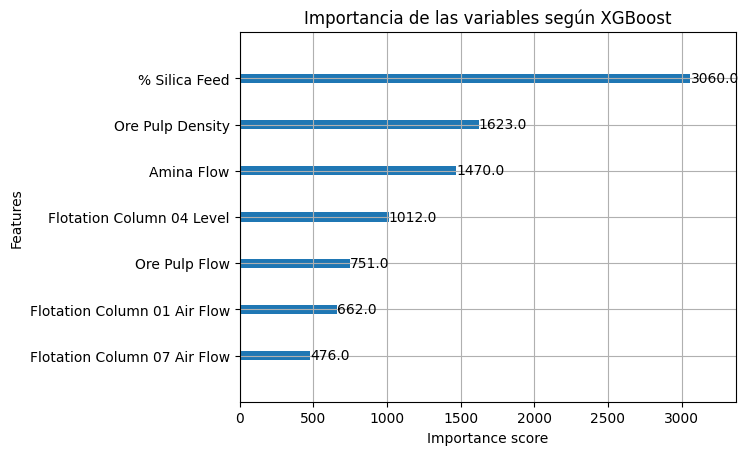

In [80]:
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# 3. Inicializar y entrenar el modelo XGBoost
# n_estimators son los árboles, learning_rate controla qué tan rápido aprende
modelo_xgb = xgb.XGBRegressor(n_estimators=150, learning_rate=0.1, random_state=42)
modelo_xgb.fit(X_train, y_train)

# 4. Evaluar el error básico
predicciones = modelo_xgb.predict(X_test)
error = mean_squared_error(y_test, predicciones) # RMSE
print(f"Error RMSE en test: {error:.4f}")

# 5. La prueba del algodón: ¿Qué variables son realmente importantes para XGBoost?
plt.figure(figsize=(10, 6))
xgb.plot_importance(modelo_xgb, importance_type='weight', max_num_features=10)
plt.title('Importancia de las variables según XGBoost')
plt.show()

In [75]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error

# 1. Inicializar el modelo naive
# La estrategia 'mean' calculará la media de % Silica Concentrate en el entrenamiento
# y usará ese mismo número estático para todas las predicciones futuras.
modelo_naive = DummyRegressor(strategy="mean")

# 2. "Entrenar" el modelo (en realidad solo está calculando la media de y_train)
modelo_naive.fit(X_train, y_train)

# 3. Realizar las predicciones sobre el conjunto de prueba
predicciones_naive = modelo_naive.predict(X_test)

# 4. Calcular el error (RMSE) para poder compararlo
error_naive = mean_squared_error(y_test, predicciones_naive)

print(f"--- COMPARACIÓN DE MODELOS ---")
print(f"Error RMSE Modelo Naive (Media): {error_naive:.4f}")
# Asumiendo que guardaste el error de tu XGBoost en la variable 'error' del paso anterior:
print(f"Error RMSE Modelo XGBoost:       {error:.4f}")

--- COMPARACIÓN DE MODELOS ---
Error RMSE Modelo Naive (Media): 1.2638
Error RMSE Modelo XGBoost:       0.6017


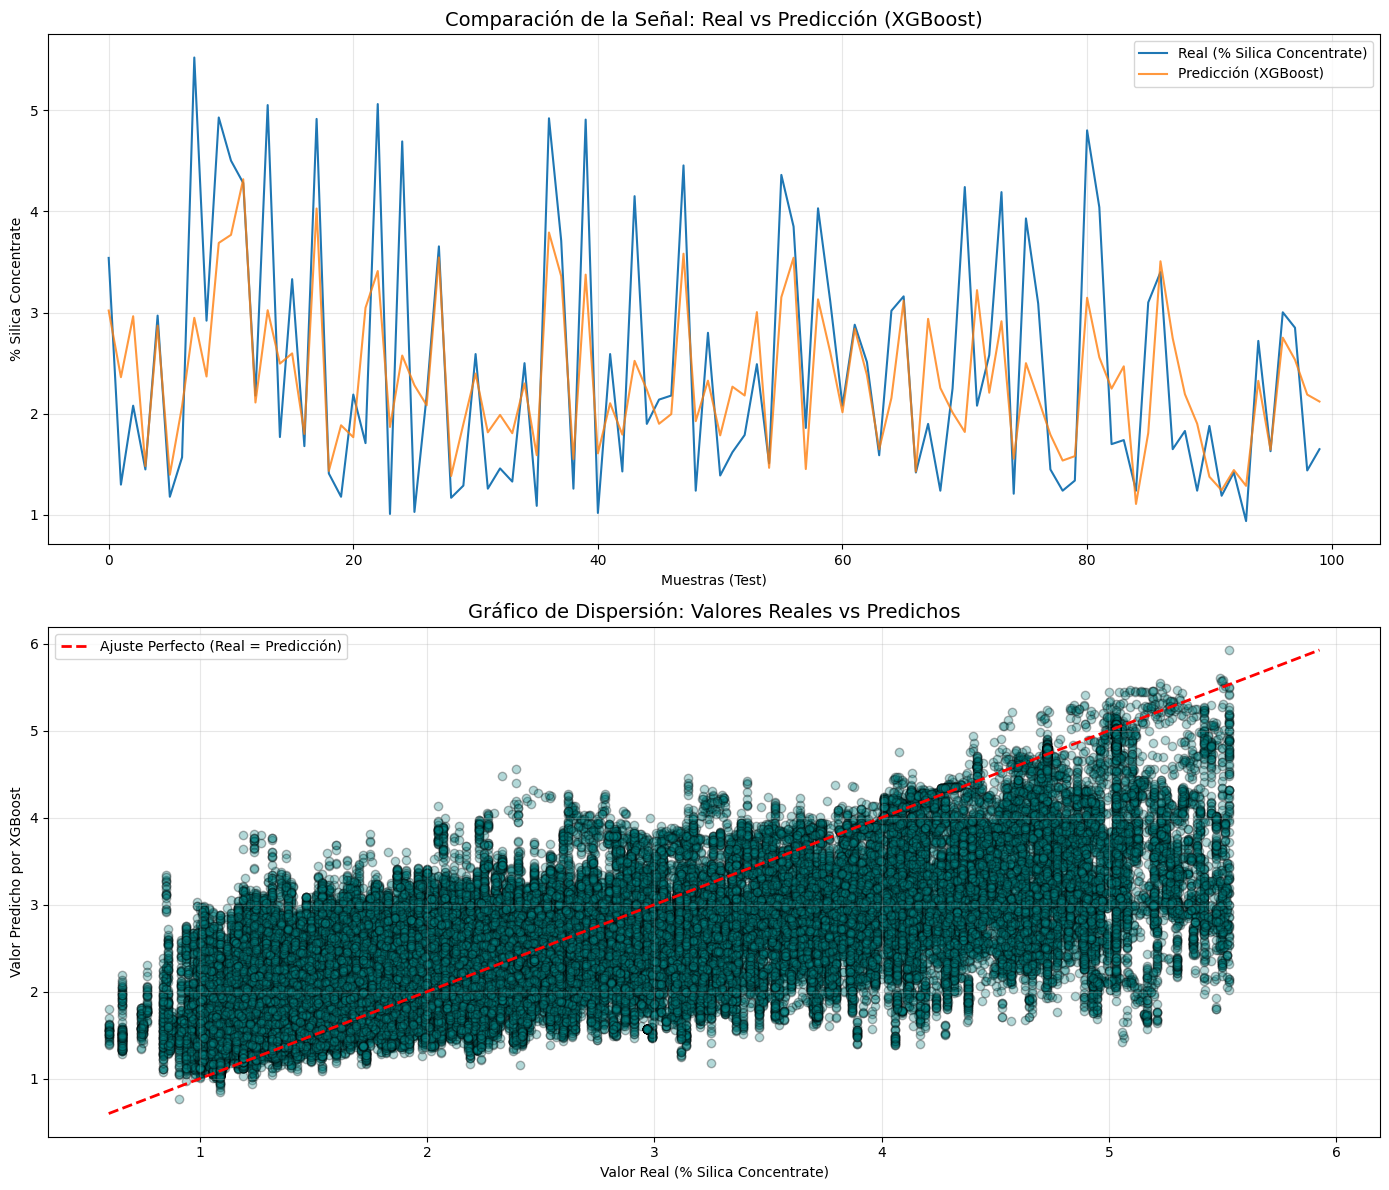

In [76]:
import matplotlib.pyplot as plt
import numpy as np

n_muestras = 100

# Es importante resetear el índice de y_test para que se alinee correctamente 
# con el array de predicciones, evitando que Matplotlib dibuje líneas caóticas.
y_test_plot = y_test.reset_index(drop=True)

# Creamos una figura con dos subgráficos (uno arriba y otro abajo)
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# ---------------------------------------------------------
# GRÁFICA 1: Señal Real vs Predicción (Línea de tiempo/muestras)
# ---------------------------------------------------------
# Dibujamos los datos reales en azul
axes[0].plot(y_test_plot[:n_muestras], label='Real (% Silica Concentrate)', color='#1f77b4', linewidth=1.5)

# Dibujamos las predicciones en naranja (con un poco de transparencia para ver si se solapan bien)
axes[0].plot(predicciones[:n_muestras], label='Predicción (XGBoost)', color='#ff7f0e', alpha=0.8, linewidth=1.5)

axes[0].set_title('Comparación de la Señal: Real vs Predicción (XGBoost)', fontsize=14)
axes[0].set_ylabel('% Silica Concentrate')
axes[0].set_xlabel('Muestras (Test)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 💡 TRUCO: Si tu set de test tiene miles de puntos, la gráfica de arriba se verá como un borrón. 
# Descomenta la siguiente línea para hacer "zoom" en las primeras 200 muestras y ver bien el ajuste:
# axes[0].set_xlim(0, 200) 


# ---------------------------------------------------------
# GRÁFICA 2: Dispersión (Gráfico Y vs Ŷ) - Ideal para Machine Learning
# ---------------------------------------------------------
axes[1].scatter(y_test_plot, predicciones, alpha=0.3, color='teal', edgecolor='k')

# Dibujamos la línea roja diagonal de "Perfección" (y = x)
min_val = min(y_test_plot.min(), predicciones.min())
max_val = max(y_test_plot.max(), predicciones.max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Ajuste Perfecto (Real = Predicción)')

axes[1].set_title('Gráfico de Dispersión: Valores Reales vs Predichos', fontsize=14)
axes[1].set_xlabel('Valor Real (% Silica Concentrate)')
axes[1].set_ylabel('Valor Predicho por XGBoost')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()